In [1]:
import obspy
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.mass_downloader.domain import RectangularDomain
from obspy import UTCDateTime
from obspy.clients.fdsn.mass_downloader import Restrictions
from obspy.clients.fdsn.header import FDSNNoDataException
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import h5py

In [2]:
def my_get_coord(waveform_id,time,inventory):
    network = waveform_id.network_code
    station = waveform_id.station_code
    location = waveform_id.location_code
    channel = waveform_id.channel_code
    if location is None:
        location = ''
    try:
        return inventory.get_coordinates(f'{network}.{station}.{location}.{channel}',time)
    except:
        for net in inventory.networks:
            if network == net.code:
                for sta in net.stations:
                    if station == sta.code:
                        if time:
                            # skip if start date before given datetime
                            if sta.start_date and sta.start_date > time:
                                continue
                            # skip if end date before given datetime
                            if sta.end_date and sta.end_date < time:
                                continue
                        coordinates = {}
                        for key in ['latitude', 'longitude']:
                            coordinates[key] = getattr(sta,key)
                        return coordinates

def sph_dist(lat1,lon1,lat2,lon2):
    R = 6371
    dLat = np.deg2rad(lat2-lat1)
    dLon = np.deg2rad(lon2-lon1) 
    a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(np.deg2rad(lat1)) * np.cos(np.deg2rad(lat2)) * np.sin(dLon/2) * np.sin(dLon/2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = R * c
    return d

In [2]:
domain = RectangularDomain(minlatitude=20, maxlatitude=54,
                           minlongitude=73, maxlongitude=135)

In [ ]:
restrict = Restrictions(
    starttime=UTCDateTime(2024, 1, 1),
    endtime=UTCDateTime(2024, 12, 15),
    network=None, station=None, location=None, channel=None,
    reject_channels_with_gaps=True,
    minimum_length=0.9,
    minimum_interstation_distance_in_m=1000,
    channel_priorities=["HH[ZNE]", "BH[ZNE]"],
    location_priorities=["", "00", "01"])

In [3]:
client = Client("ISC")

In [4]:
t1 = UTCDateTime("2023-01-01T00:00:00")
t2 = UTCDateTime("2024-07-01T00:00:00")
cat = client.get_events(starttime=t1, endtime=t2,
                        minmagnitude=6,maxmagnitude=10,
                        maxdepth=60,
                        # eventtype='earthquake',
                        minlatitude=20, maxlatitude=54, minlongitude=73, maxlongitude=135,
                        includearrivals=True)

In [106]:
tmp = client.get_events(eventid=609301,includearrivals=True)

In [125]:
cat = cat.filter("depth < 60000")

In [8]:
pick = cat[0].picks[0]

In [11]:
client_sta = Client("IRIS")

In [14]:
stations = client_sta.get_stations(network=pick.waveform_id.network_code,station=pick.waveform_id.station_code)

In [194]:
getattr(cat[0].picks[0].waveform_id,'location_code')

In [125]:
cat[3].picks[0]

Pick
	     resource_id: ResourceIdentifier(id="smi:ISC/pickid=1154043488")
	            time: UTCDateTime(2024, 1, 9, 8, 59, 20, 50000)
	     waveform_id: WaveformStreamID(network_code='JP', station_code='JSD', channel_code='BHZ')
	      phase_hint: 'P'
	 evaluation_mode: 'automatic'

In [15]:
picks = []
for event in cat:
    lon1 = event.origins[0].longitude
    lat1 = event.origins[0].latitude
    for pick in event.picks:
        if pick.phase_hint != 'P':
            continue
        sta_coord = my_get_coord(pick.waveform_id, pick.time, stations)
        if sta_coord is None:
            try:
                tmp_sta = client_sta.get_stations(network=pick.waveform_id.network_code,station=pick.waveform_id.station_code)
                sta_coord = my_get_coord(pick.waveform_id, pick.time, tmp_sta)
                stations = stations + tmp_sta
            except:
                pass
        if sta_coord is not None:
            dist = sph_dist(lat1, lon1, sta_coord['latitude'], sta_coord['longitude'])
            if dist < 500:
                picks.append(pick)
        

In [16]:
pick_dict = {'network_code':[],'station_code':[],'channel_code':[],'location_code':[],'time':[],'resource_id':[],'object_id':[]}
for pick in picks:
    wf_id = pick.waveform_id
    pick_dict['network_code'].append(wf_id.network_code)
    pick_dict['station_code'].append(wf_id.station_code)
    pick_dict['channel_code'].append(wf_id.channel_code)
    pick_dict['location_code'].append(wf_id.location_code)
    pick_dict['resource_id'].append(pick.resource_id.id)
    pick_dict['object_id'].append(pick.resource_id._object_id)
    pick_dict['time'].append(pick.time)

In [17]:
df = pd.DataFrame(pick_dict)
df.to_csv('ISC_chinamainland_mag6_depth60_dis500_230101_240701.csv',index=False)

In [88]:
dtype_dict = {'location_code':str,'network_code':str,'station_code':str,'channel_code':str}
df = pd.read_csv('GFZ_mag5_depth60_dis500_240101_240701.csv',parse_dates=['time'],dtype=dtype_dict,keep_default_na=False)

In [74]:
clients = [Client("GFZ"),Client("IRIS"),Client("ETH")]

In [90]:
used_row = []
with h5py.File('GFZ_mag5_depth60_dis500_240101_240701.hdf5','w') as f:
    for i,row in df.iterrows():
        if pd.isna(row.location_code):
            location_code = ''
        else:
            location_code = row.location_code
        c_code = row.channel_code[:-1]
        c_code = f'{c_code}Z,{c_code}N,{c_code}E'
        for client in clients:
            try:
                wvfm = client.get_waveforms(network=row.network_code,station=row.station_code,location=location_code,channel=c_code,
                                    starttime=obspy.UTCDateTime(row.time) - 40, endtime=obspy.UTCDateTime(row.time) + 60)
                if len(wvfm) < 3:
                    continue
                if wvfm[0].stats.sampling_rate < 100:
                    continue
                for trace in wvfm:
                    f.create_dataset(f'{row.resource_id}{trace.stats.channel[-1]}',data=trace.data)
                used_row.append(i)
                break
            except FDSNNoDataException:
                continue

In [94]:
len(df.iloc[used_row])

49

In [73]:
#client = Client("IRIS")
client.get_waveforms(network='II',station='ERM',location='00',channel='BHZ,BHN,BHE',
                                starttime=obspy.UTCDateTime(row.time) - 40, endtime=obspy.UTCDateTime(row.time) + 60)

1 Trace(s) in Stream:
II.ERM.00.BHZ | 2024-06-29T06:49:51.719538Z - 2024-06-29T06:51:31.669538Z | 20.0 Hz, 2000 samples

In [89]:
df.iloc[i-1:i+1]

,network_code,station_code,channel_code,location_code,time,resource_id,object_id
612,IU,ADK,BHZ,00,2024-03-12 20:57:08.360000+00:00,smi:org.gfz-potsdam.de/geofon/20240312.205708....,134767740911744
613,NA,SMRT,BHZ,,2024-03-12 20:00:23.880000+00:00,smi:org.gfz-potsdam.de/geofon/20240312.200023....,134767741219088


In [86]:
df.iloc[i].network_code

nan

In [18]:
df.iloc[0].time

Timestamp('2024-06-30 16:07:27.660000+0000', tz='UTC')

In [135]:
client_sta = Client("IRIS")

In [136]:
stations = client_sta.get_stations(network='TM',station='MHIT')

In [201]:
tmp_sta = client_sta.get_stations(network='C1',station='AP01')

In [203]:
tmp_sta + stations

Inventory created at 2024-12-18T09:16:32.328580Z
	Created by: ObsPy 1.4.1
		    https://www.obspy.org
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (2):
			C1, TM
		Stations (2):
			C1.AP01 (Chacalluta)
			TM.MHIT (Mueang, MaeHongSon)
		Channels (0):


In [167]:
cat[0].picks[1].time

2024-06-30T22:58:47.020000Z

In [170]:
my_get_coord('TM','MHIT','00','HHZ',cat[0].picks[1].time,stations)

{'latitude': 19.3148, 'longitude': 97.9632}

In [165]:
for net in stations.networks:
    if 'TM' == net.code:
        print('network found!')
        for sta in net.stations:
            if 'MHIT' == sta.code:
                print('station found!')
                print(getattr(sta,'latitude'))

network found!
station found!
19.3148


In [ ]:
for event in cat:
    

In [97]:
cat[2]

Event:	2024-12-15T15:03:37.595000Z | -18.565, -175.273 | 5.9  mww | manual

	            resource_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000nz38&format=quakeml")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='us', creation_time=UTCDateTime(2024, 12, 16, 15, 6, 37, 547000))
	    preferred_origin_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/us7000nz38/us/1734276028040/product.xml")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/us7000nz38/us/1734276028040/product.xml#magnitude")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements

In [83]:
stations = client.get_stations(network='KR',station='OHH')

In [91]:
stations.networks[0].stations[0]

Station OHH (Osh, Kyrgyzstan)
	Station Code: OHH
	Channel Count: 0/9 (Selected/Total)
	2008-03-23T00:00:00.000000Z - 
	Access: open 
	Latitude: 40.5244, Longitude: 72.7850, Elevation: 800.0 m
	Available Channels:


In [19]:
mags = [x.magnitudes[0].mag for x in cat]

<Axes: ylabel='Count'>

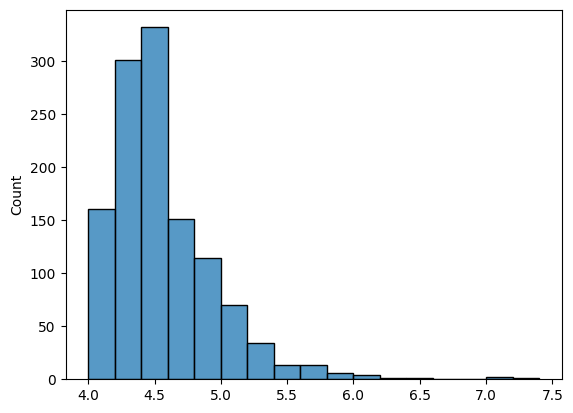

In [24]:
sns.histplot(mags,bins=17)

In [45]:
cat[0].resource_id.id

'smi:service.iris.edu/fdsnws/event/1/query?eventid=11913321'

In [48]:
ev = client.get_events(eventid=cat[0].resource_id.id.split('=')[1],includearrivals=True)

In [56]:
tmp = pd.DataFrame({'x':[1,2,3,4]})

In [58]:
tmp.iloc[[0,3]]

,x
0,1
3,4
